In [1]:
# Generating ground truth

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:

# Mackey–Glass parameters
a, b, n = 0.2, 0.1, 10
tau, dt = 17.0, 0.1
total_points = 100001
history_length = int(tau / dt)

def Mackey_Glass(xt, xtau, a=0.2, b=0.1, n=10):
    return -b * xt + a * xtau / (1 + xtau**n)

def Mackey_Glass_rk4(xt, xtau, a=0.2, b=0.1, n=10, h=0.1):
    k1 = h * Mackey_Glass(xt, xtau, a, b, n)
    k2 = h * Mackey_Glass(xt + 0.5 * k1, xtau, a, b, n)
    k3 = h * Mackey_Glass(xt + 0.5 * k2, xtau, a, b, n)
    k4 = h * Mackey_Glass(xt + k3, xtau, a, b, n)
    return xt + (k1 + 2*k2 + 2*k3 + k4) / 6.0

# Initialize history buffer with random values
np.random.seed(2025)
buffer = 1.2 + np.random.rand(history_length)

# Full series length including history
series_length = total_points + history_length
x = np.zeros(series_length)

# Fill initial delay values
x[:history_length] = buffer

# Integrate
for t in range(history_length, series_length - 1):
    xt = x[t]
    xtau = x[t - history_length]
    x[t + 1] = Mackey_Glass_rk4(xt, xtau, a, b, n, h=dt)

# Extract the actual generated time series (after initial history)
mg_series = x[history_length:].reshape(1, -1)

print(mg_series.shape)  # should print (1, total_points)

data_clean = mg_series[:,::10]


(1, 100001)


In [4]:
#Reproducibility
seed = 2029
np.random.seed(seed)

# ---------------------------
# Noise utility
# ---------------------------
def add_relative_gaussian_noise(X_clean, noise_scale):
    """Adds relative Gaussian noise to dataset X_clean."""
    signal_std = np.std(X_clean, axis=1, keepdims=True)
    noise = np.random.normal(0.0, noise_scale * signal_std, X_clean.shape)
    return X_clean + noise

# ---------------------------
# Generate and Save Multiple Noise Levels
# ---------------------------
noise_levels = [0.0, 0.1, 0.2, 0.3]

for nl in noise_levels:
    # Add noise BEFORE normalization
    data_noisy = add_relative_gaussian_noise(data_clean, nl)
    # Save
    save_dict = {
        "data": data_noisy,   # shape (3, T)
        "meta": {
        "noise_scale": nl
        }
    }
    np.save(f"mg_noise_{int(nl*100)}.npy", save_dict)
    print(f"Saved mg_noise_{int(nl*100)}.npy")

Saved mg_noise_0.npy
Saved mg_noise_10.npy
Saved mg_noise_20.npy
Saved mg_noise_30.npy


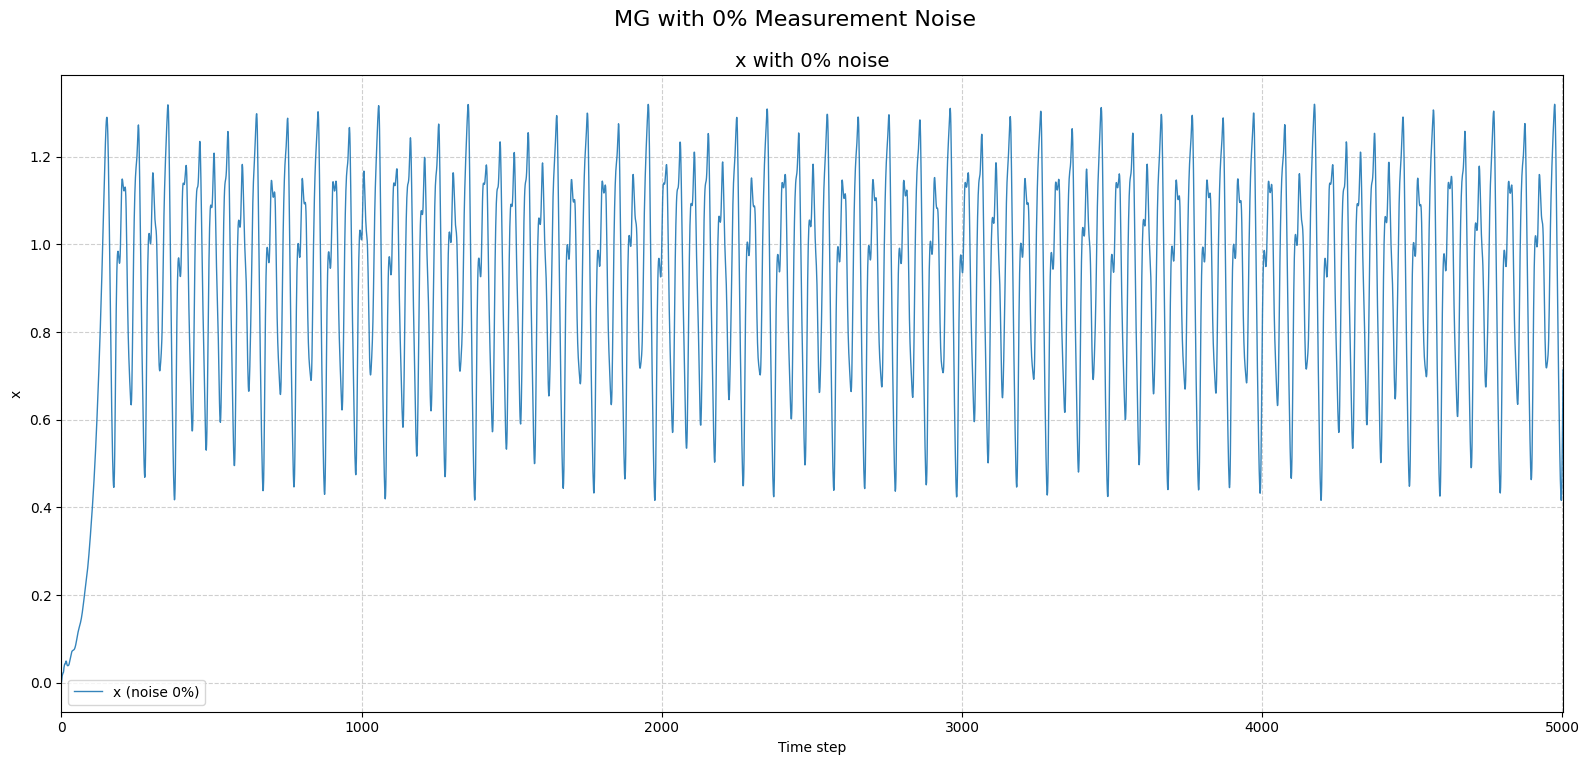

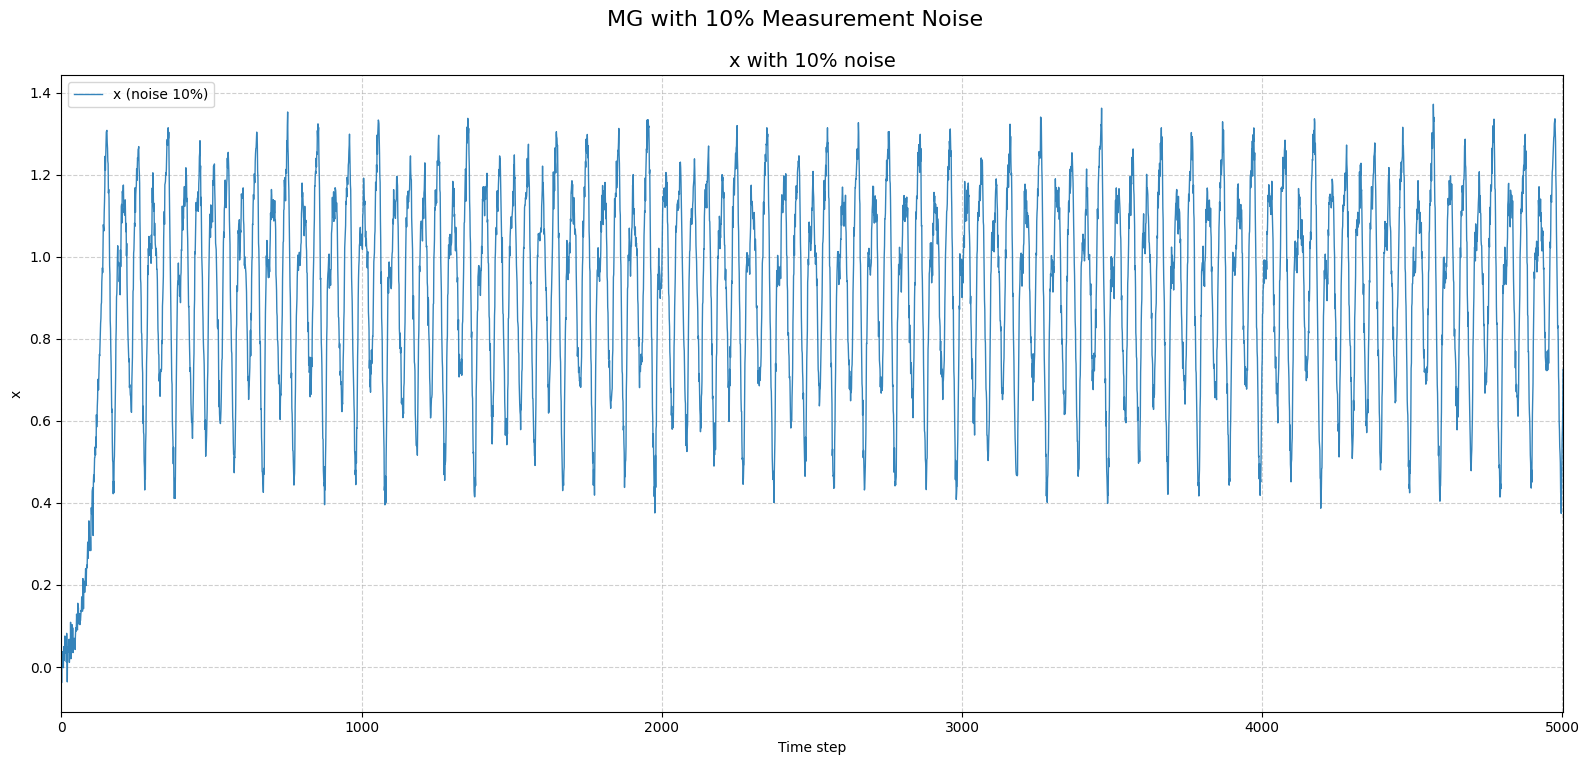

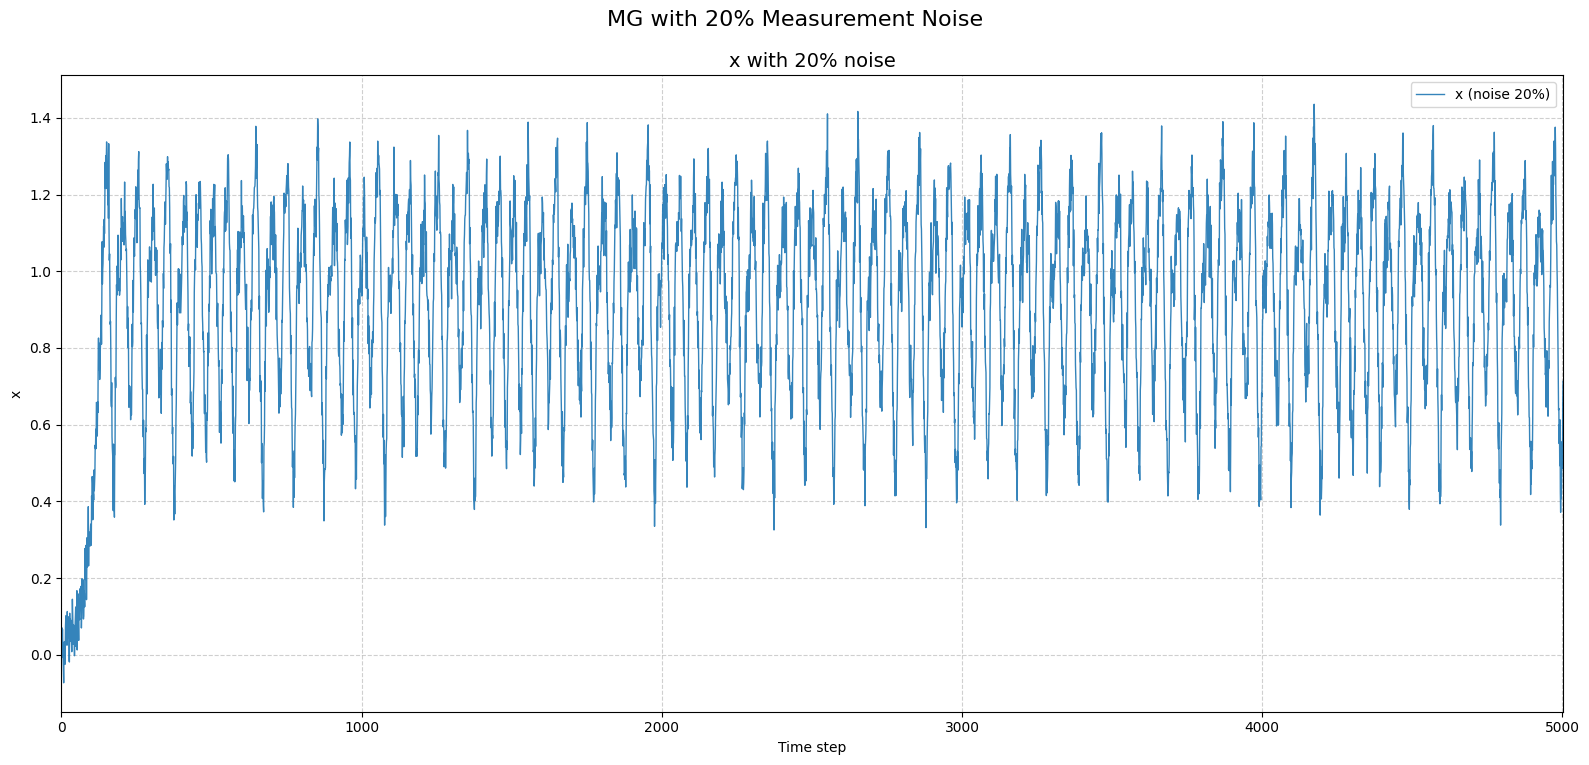

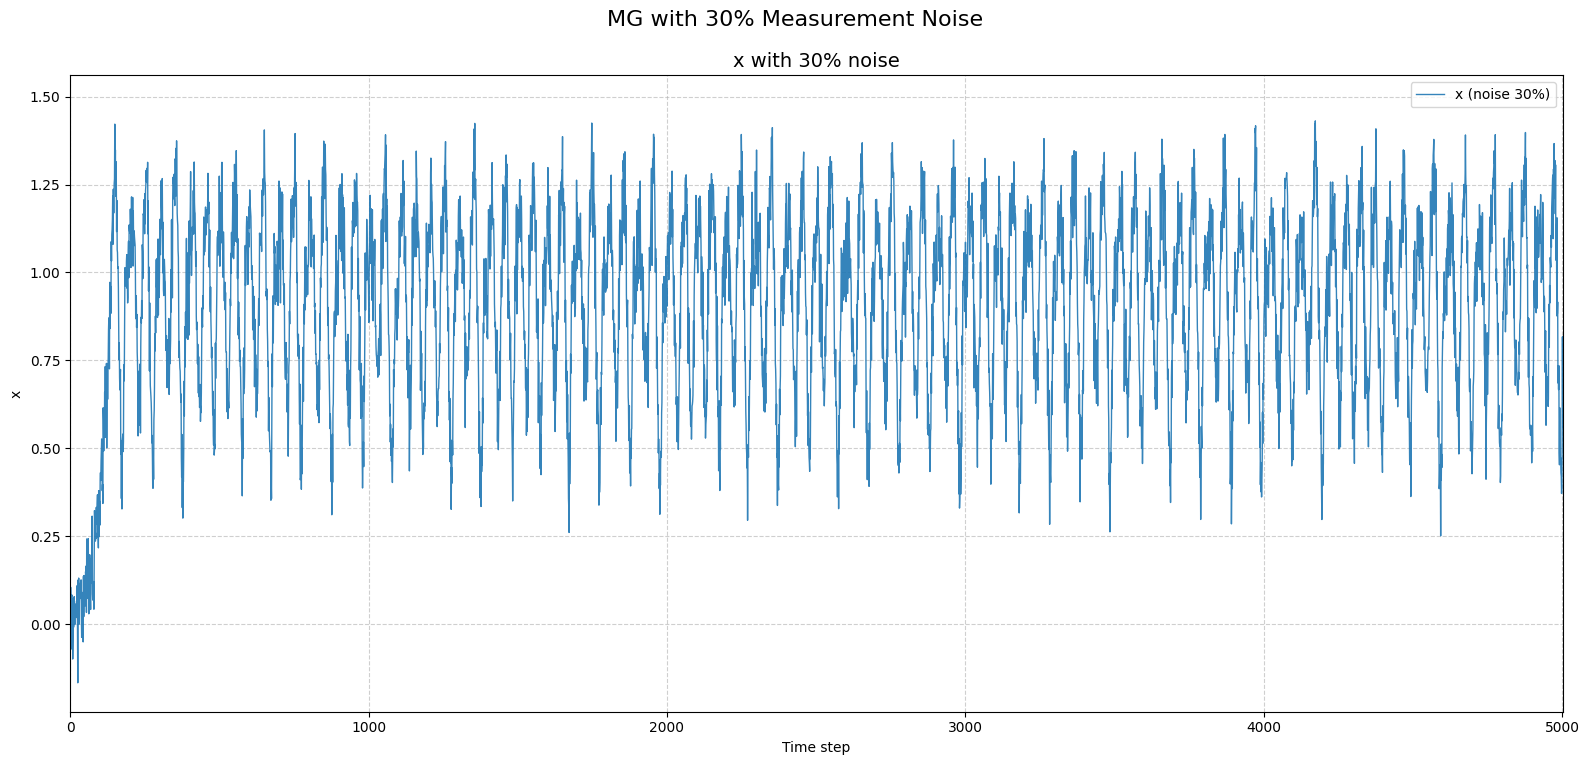

In [5]:
import numpy as np
import matplotlib.pyplot as plt
# -----------------------------------------------------------
# Load datasets with different noise levels
# -----------------------------------------------------------
noise_levels = [0, 10, 20, 30]
datasets = {}

for nl in noise_levels:
    data = np.load(f"mg_noise_{nl}.npy", allow_pickle=True).item()
    datasets[nl] = data["data"].T  # shape (T, 3)

# -----------------------------------------------------------
# Plot: one figure per noise level
# -----------------------------------------------------------
variables = ["x"]
timesteps = np.arange(datasets[0].shape[0])

for nl in noise_levels:
    plt.figure(figsize=(16, 8))
    for i in range(1):  # loop over variables
        plt.subplot(1, 1, i + 1)
        plt.plot(timesteps, datasets[nl][:, i],
                 label=f"{variables[i]} (noise {nl}%)",
                 linewidth=1.0, alpha=0.9)
        plt.title(f"{variables[i]} with {nl}% noise", fontsize=14)
        plt.xlabel("Time step")
        plt.ylabel(variables[i])
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.xlim(0, 5001)
    plt.suptitle(f"MG with {nl}% Measurement Noise", fontsize=16, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    plt.show()
